In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [57]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns
from scipy.stats import spearmanr
import os

os.chdir("../../../notebooks/ChopTFs/pipeline/")
import time_normalization_helpers

# 1. Filtering data to tiles appropriate for fit

In [96]:
mult_rep_activities = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/time_normalization/DBD_time_normalized_activities_bootstrapped_error_active_pval.csv", index_col = 0)
#dbd_norm_activities = dbd_norm_activities[["ADseq",  "AD_end", "AD_BC", "RPTR_BC", "time", "rep", "shifted_activity"]]
mult_rep_activities = mult_rep_activities.rename(columns = {"mean" : "activity"})
mult_rep_activities["error"] = (mult_rep_activities["ci_hi"] - mult_rep_activities["ci_low"]) / (2 * 1.96)
mult_rep_activities = mult_rep_activities[mult_rep_activities["time"] <= 30]
mult_rep_activities

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,-1.199781,0.131956,2,ns,0.339729
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,2,ns,0.265582
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,0.035151,0.703783,2,activator,0.170569
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,-0.175927,0.829249,2,ns,0.256423
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,2,ns,0.368413
...,...,...,...,...,...,...,...,...
27549,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,0,0.182490,-0.216894,0.602357,2,ns,0.208992
27550,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,5,-0.093504,-0.346717,0.105645,2,ns,0.115398
27551,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,10,0.009890,-0.883891,0.659086,2,ns,0.393616
27552,YYQALRQSQESSARAYKMQQGISISPSLPSFPPSSPSMTT,15,0.082184,-0.211983,0.440839,2,ns,0.166536


In [97]:
mult_rep_activities["class"].value_counts()

ns           13359
activator     5781
repressor      350
Name: class, dtype: int64

In [98]:
all_tiles = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/time_normalization/DBD_time_normalized_activities_bootstrapped_error_and_no_CIs.csv", index_col = 0)
all_tiles = all_tiles[all_tiles["time"] <= 30]
all_tiles = all_tiles.rename(columns = {"mean" : "activity"})
all_tiles

,ADseq,time,activity,ci_low,ci_hi,n_barcodes
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,-1.199781,0.131956,2
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,2
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,0.035151,0.703783,2
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,-0.175927,0.829249,2
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,2
...,...,...,...,...,...,...
50170,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,0,-0.109257,NaN,NaN,1
50171,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,5,-0.472879,NaN,NaN,1
50172,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,10,-0.496125,NaN,NaN,1
50173,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,15,-0.554889,NaN,NaN,1


In [103]:
activities = pd.merge(all_tiles[["ADseq", "time", "activity"]], mult_rep_activities, how = 'left')
activities

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,-1.199781,0.131956,2.0,ns,0.339729
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,2.0,ns,0.265582
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,0.035151,0.703783,2.0,activator,0.170569
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,-0.175927,0.829249,2.0,ns,0.256423
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,2.0,ns,0.368413
...,...,...,...,...,...,...,...,...
55389,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,0,-0.109257,NaN,NaN,NaN,NaN,NaN
55390,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,5,-0.472879,NaN,NaN,NaN,NaN,NaN
55391,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,10,-0.496125,NaN,NaN,NaN,NaN,NaN
55392,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,15,-0.554889,NaN,NaN,NaN,NaN,NaN


In [104]:
activities["class"].value_counts()

ns           13359
activator     5781
repressor      350
Name: class, dtype: int64

In [105]:
no_ci_mask = activities['ci_low'].isna()

# Get ADseqs that have a t=0 measurement
seqs_with_t0 = set(activities[no_ci_mask & (activities['time'] == 0)]['ADseq'])

# Remove no-CI rows whose ADseq has no t=0
activities = activities[
    ~no_ci_mask | activities['ADseq'].isin(seqs_with_t0)
]

# Recompute mask after filtering
no_ci_mask = activities['ci_low'].isna()

t0_means = (activities[no_ci_mask & (activities['time'] == 0)]
            .set_index('ADseq')['activity'])

def classify_no_ci(row):
    if row['time'] == 0:
        return 'ns'
    diff = row['activity'] - t0_means[row['ADseq']]
    if diff > 0.78:
        return 'activator'
    elif diff < -0.78:
        return 'repressor'
    else:
        return 'ns'

activities.loc[no_ci_mask, 'class'] = (
    activities[no_ci_mask].apply(classify_no_ci, axis=1)
)
activities = activities.dropna(subset = "class")
activities

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error
0,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,0,-0.533217,-1.199781,0.131956,2.0,ns,0.339729
1,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,5,0.036563,-0.531644,0.509437,2.0,ns,0.265582
2,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,10,0.432846,0.035151,0.703783,2.0,activator,0.170569
3,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,15,0.317114,-0.175927,0.829249,2.0,ns,0.256423
4,AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS,30,0.469307,-0.223151,1.221027,2.0,ns,0.368413
...,...,...,...,...,...,...,...,...
55389,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,0,-0.109257,NaN,NaN,NaN,ns,NaN
55390,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,5,-0.472879,NaN,NaN,NaN,ns,NaN
55391,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,10,-0.496125,NaN,NaN,NaN,ns,NaN
55392,YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT,15,-0.554889,NaN,NaN,NaN,ns,NaN


In [106]:
activities["class"].value_counts()

ns           36489
activator    15954
repressor     2154
Name: class, dtype: int64

In [107]:
activities["ADseq"].value_counts()

YYQNQQLHPTHHRRMMSTPNMAHGKPALLSLSSALFQTQT    5
AAAPVATTASAAPVLSEVDQKKDVASPFQIHSSVLESVFS    5
AAAYSVEPKKPIVQTPASPASPRAKRSVASSPVPASGGVK    5
AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS    5
AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS    5
                                           ..
LPELVQPVQPTVQPTVEQTVHSVEASPATPSEDLEALSPG    1
LPPIIVEDPNDTVAMKRARNTLAARKSRQRKMQRFDELED    1
TSPDINDSPFNDSFDCSPMFQNEPTMANSDWFSLFPEEET    1
QTNTYPVITFFLPGPLNSTSLHLATFRSSSSLPATIPPFD    1
PKASVLPVPPSPVVNVPSSPAPQLAPSPSPSRASSTKPSS    1
Name: ADseq, Length: 11032, dtype: int64

In [109]:
# get last timepoint per ADseq
last = (
    activities.sort_values("time")
      .groupby("ADseq")
      .tail(1)
)

# find ADseqs where the last time point is active
keep_adseq = (
    last.groupby("ADseq")["class"]
    .apply(lambda x: (x == "activator").any())
)

# filter original df
active_tile_activities = activities[activities["ADseq"].isin(keep_adseq[keep_adseq].index)]
active_tile_activities

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error
10,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2.0,ns,0.059735
11,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2.0,ns,0.332233
12,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2.0,activator,0.247404
13,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2.0,ns,0.332646
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2.0,activator,0.271013
...,...,...,...,...,...,...,...,...
55384,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,0,0.040089,NaN,NaN,NaN,ns,NaN
55385,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,5,0.490969,NaN,NaN,NaN,ns,NaN
55386,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,10,1.303383,NaN,NaN,NaN,activator,NaN
55387,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,15,1.037466,NaN,NaN,NaN,activator,NaN


In [110]:
active_tile_activities["ADseq"].value_counts()

YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS    5
AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS    5
AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS    5
AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN    5
AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI    5
                                           ..
LTNLTSPSIYNESPDFTDTFEVSPNFEHGDFGNSSGDPWF    4
AWTRGIGGTRASHRAFWQGCPSRRNVVPHSDWDLKDASKC    3
VSPQDLLIQEPFMSAPNSTALTALTSPSIYNESPDFNDGY    3
VLDEELEVAERIRTSTTRRRSGTSTSPPATSHSSVSGVGS    2
DLSTPPFDSPGYFSHDPSPMLSDDFGSEQWDSLFPANDPF    2
Name: ADseq, Length: 4717, dtype: int64

In [111]:
expected = active_tile_activities["time"].unique()

def ok(grp):
    t = set(grp["time"].unique())

    missing = [x for x in expected if x not in t]

    if len(missing) > 1: # Want at least 4 time points
        return False

    if len(missing) <= 1:
        return True

    # check if missing are isolated in the expected sequence
    idx = np.where(np.isin(expected, missing))[0]

    # if indices are consecutive → bad
    if len(idx) > 1 and np.any(np.diff(idx) == 1):
        return False

    return True

active_tile_activities_count_filtered = active_tile_activities.groupby("ADseq").filter(ok)
active_tile_activities_count_filtered

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error
10,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2.0,ns,0.059735
11,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2.0,ns,0.332233
12,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2.0,activator,0.247404
13,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2.0,ns,0.332646
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2.0,activator,0.271013
...,...,...,...,...,...,...,...,...
55384,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,0,0.040089,NaN,NaN,NaN,ns,NaN
55385,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,5,0.490969,NaN,NaN,NaN,ns,NaN
55386,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,10,1.303383,NaN,NaN,NaN,activator,NaN
55387,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,15,1.037466,NaN,NaN,NaN,activator,NaN


In [112]:
active_tile_activities_count_filtered["ADseq"].value_counts()

YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS    5
AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS    5
AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS    5
AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN    5
AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI    5
                                           ..
LTNLTSPSIYNESPDFTDTFEVSPNFEHGDFGNSSGDPWF    4
HTPMFDELDLIMDGCKVNSSDDWVALFGDDHDIVGEEPIL    4
GSGTPQRKGSVASTGQPDNIRHYHHVPTLRNLANERSTVL    4
FCIAPRRSSSSLNTILPFDSSSFTTDNHQQSWLPSPPPQQ    4
DSFMSAPNSAALTSLTSPSDFNDSPYGDSYDVSPNFGGND    4
Name: ADseq, Length: 4713, dtype: int64

In [113]:
# --- further filter to ensure time=0 exists ---
active_tile_activities_count_filtered = active_tile_activities_count_filtered.groupby('ADseq').filter(lambda x: 0 in x['time'].values)
active_tile_activities_count_filtered

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error
10,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2.0,ns,0.059735
11,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2.0,ns,0.332233
12,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2.0,activator,0.247404
13,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2.0,ns,0.332646
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2.0,activator,0.271013
...,...,...,...,...,...,...,...,...
55384,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,0,0.040089,NaN,NaN,NaN,ns,NaN
55385,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,5,0.490969,NaN,NaN,NaN,ns,NaN
55386,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,10,1.303383,NaN,NaN,NaN,activator,NaN
55387,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,15,1.037466,NaN,NaN,NaN,activator,NaN


In [114]:
active_tile_activities_count_filtered["ADseq"].value_counts()

YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS    5
AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS    5
AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS    5
AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN    5
AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI    5
                                           ..
LTNLTSPSIYNESPDFTDTFEVSPNFEHGDFGNSSGDPWF    4
HTPMFDELDLIMDGCKVNSSDDWVALFGDDHDIVGEEPIL    4
GSGTPQRKGSVASTGQPDNIRHYHHVPTLRNLANERSTVL    4
FCIAPRRSSSSLNTILPFDSSSFTTDNHQQSWLPSPPPQQ    4
DSFMSAPNSAALTSLTSPSDFNDSPYGDSYDVSPNFGGND    4
Name: ADseq, Length: 4713, dtype: int64

In [115]:
activities_norm = active_tile_activities_count_filtered.copy()

# map time=0 activity per ADseq directly
baseline = activities_norm[activities_norm["time"] == 0].set_index("ADseq")["activity"]
activities_norm["activity_norm"] = (activities_norm["activity"] - activities_norm["ADseq"].map(baseline)).clip(lower=0)

#activities_norm = activities_norm.drop(columns = ["activity_0"])
activities_norm

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm
10,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2.0,ns,0.059735,0.000000
11,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2.0,ns,0.332233,0.246383
12,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2.0,activator,0.247404,0.781723
13,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2.0,ns,0.332646,0.987393
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2.0,activator,0.271013,1.210488
...,...,...,...,...,...,...,...,...,...
55384,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,0,0.040089,NaN,NaN,NaN,ns,NaN,0.000000
55385,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,5,0.490969,NaN,NaN,NaN,ns,NaN,0.450881
55386,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,10,1.303383,NaN,NaN,NaN,activator,NaN,1.263294
55387,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,15,1.037466,NaN,NaN,NaN,activator,NaN,0.997377


In [116]:
activities_norm["ci_low_norm"] = activities_norm["ci_low"] - activities_norm["activity"] + activities_norm["activity_norm"]
activities_norm["ci_hi_norm"] = activities_norm["ci_hi"] - activities_norm["activity"] + activities_norm["activity_norm"]
activities_norm

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm,ci_low_norm,ci_hi_norm
10,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2.0,ns,0.059735,0.000000,-0.114075,0.120087
11,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2.0,ns,0.332233,0.246383,-0.498641,0.803710
12,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2.0,activator,0.247404,0.781723,0.282038,1.251861
13,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2.0,ns,0.332646,0.987393,0.125816,1.429790
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2.0,activator,0.271013,1.210488,0.642456,1.704829
...,...,...,...,...,...,...,...,...,...,...,...
55384,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,0,0.040089,NaN,NaN,NaN,ns,NaN,0.000000,NaN,NaN
55385,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,5,0.490969,NaN,NaN,NaN,ns,NaN,0.450881,NaN,NaN
55386,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,10,1.303383,NaN,NaN,NaN,activator,NaN,1.263294,NaN,NaN
55387,YYLHYLHRHNGCPISIQSQDQSFSTEDDIISPTGTQPFLS,15,1.037466,NaN,NaN,NaN,activator,NaN,0.997377,NaN,NaN


In [117]:
activities_norm.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/activities_to_fit.csv")

# Baseline activity over time

100%|██████████| 4/4 [00:00<00:00, 46.45it/s]


(<Figure size 2400x3600 with 4 Axes>,
 array([<Axes: ylabel='5 min.'>, <Axes: ylabel='10 min.'>,
        <Axes: ylabel='15 min.'>, <Axes: ylabel='30 min.'>], dtype=object))

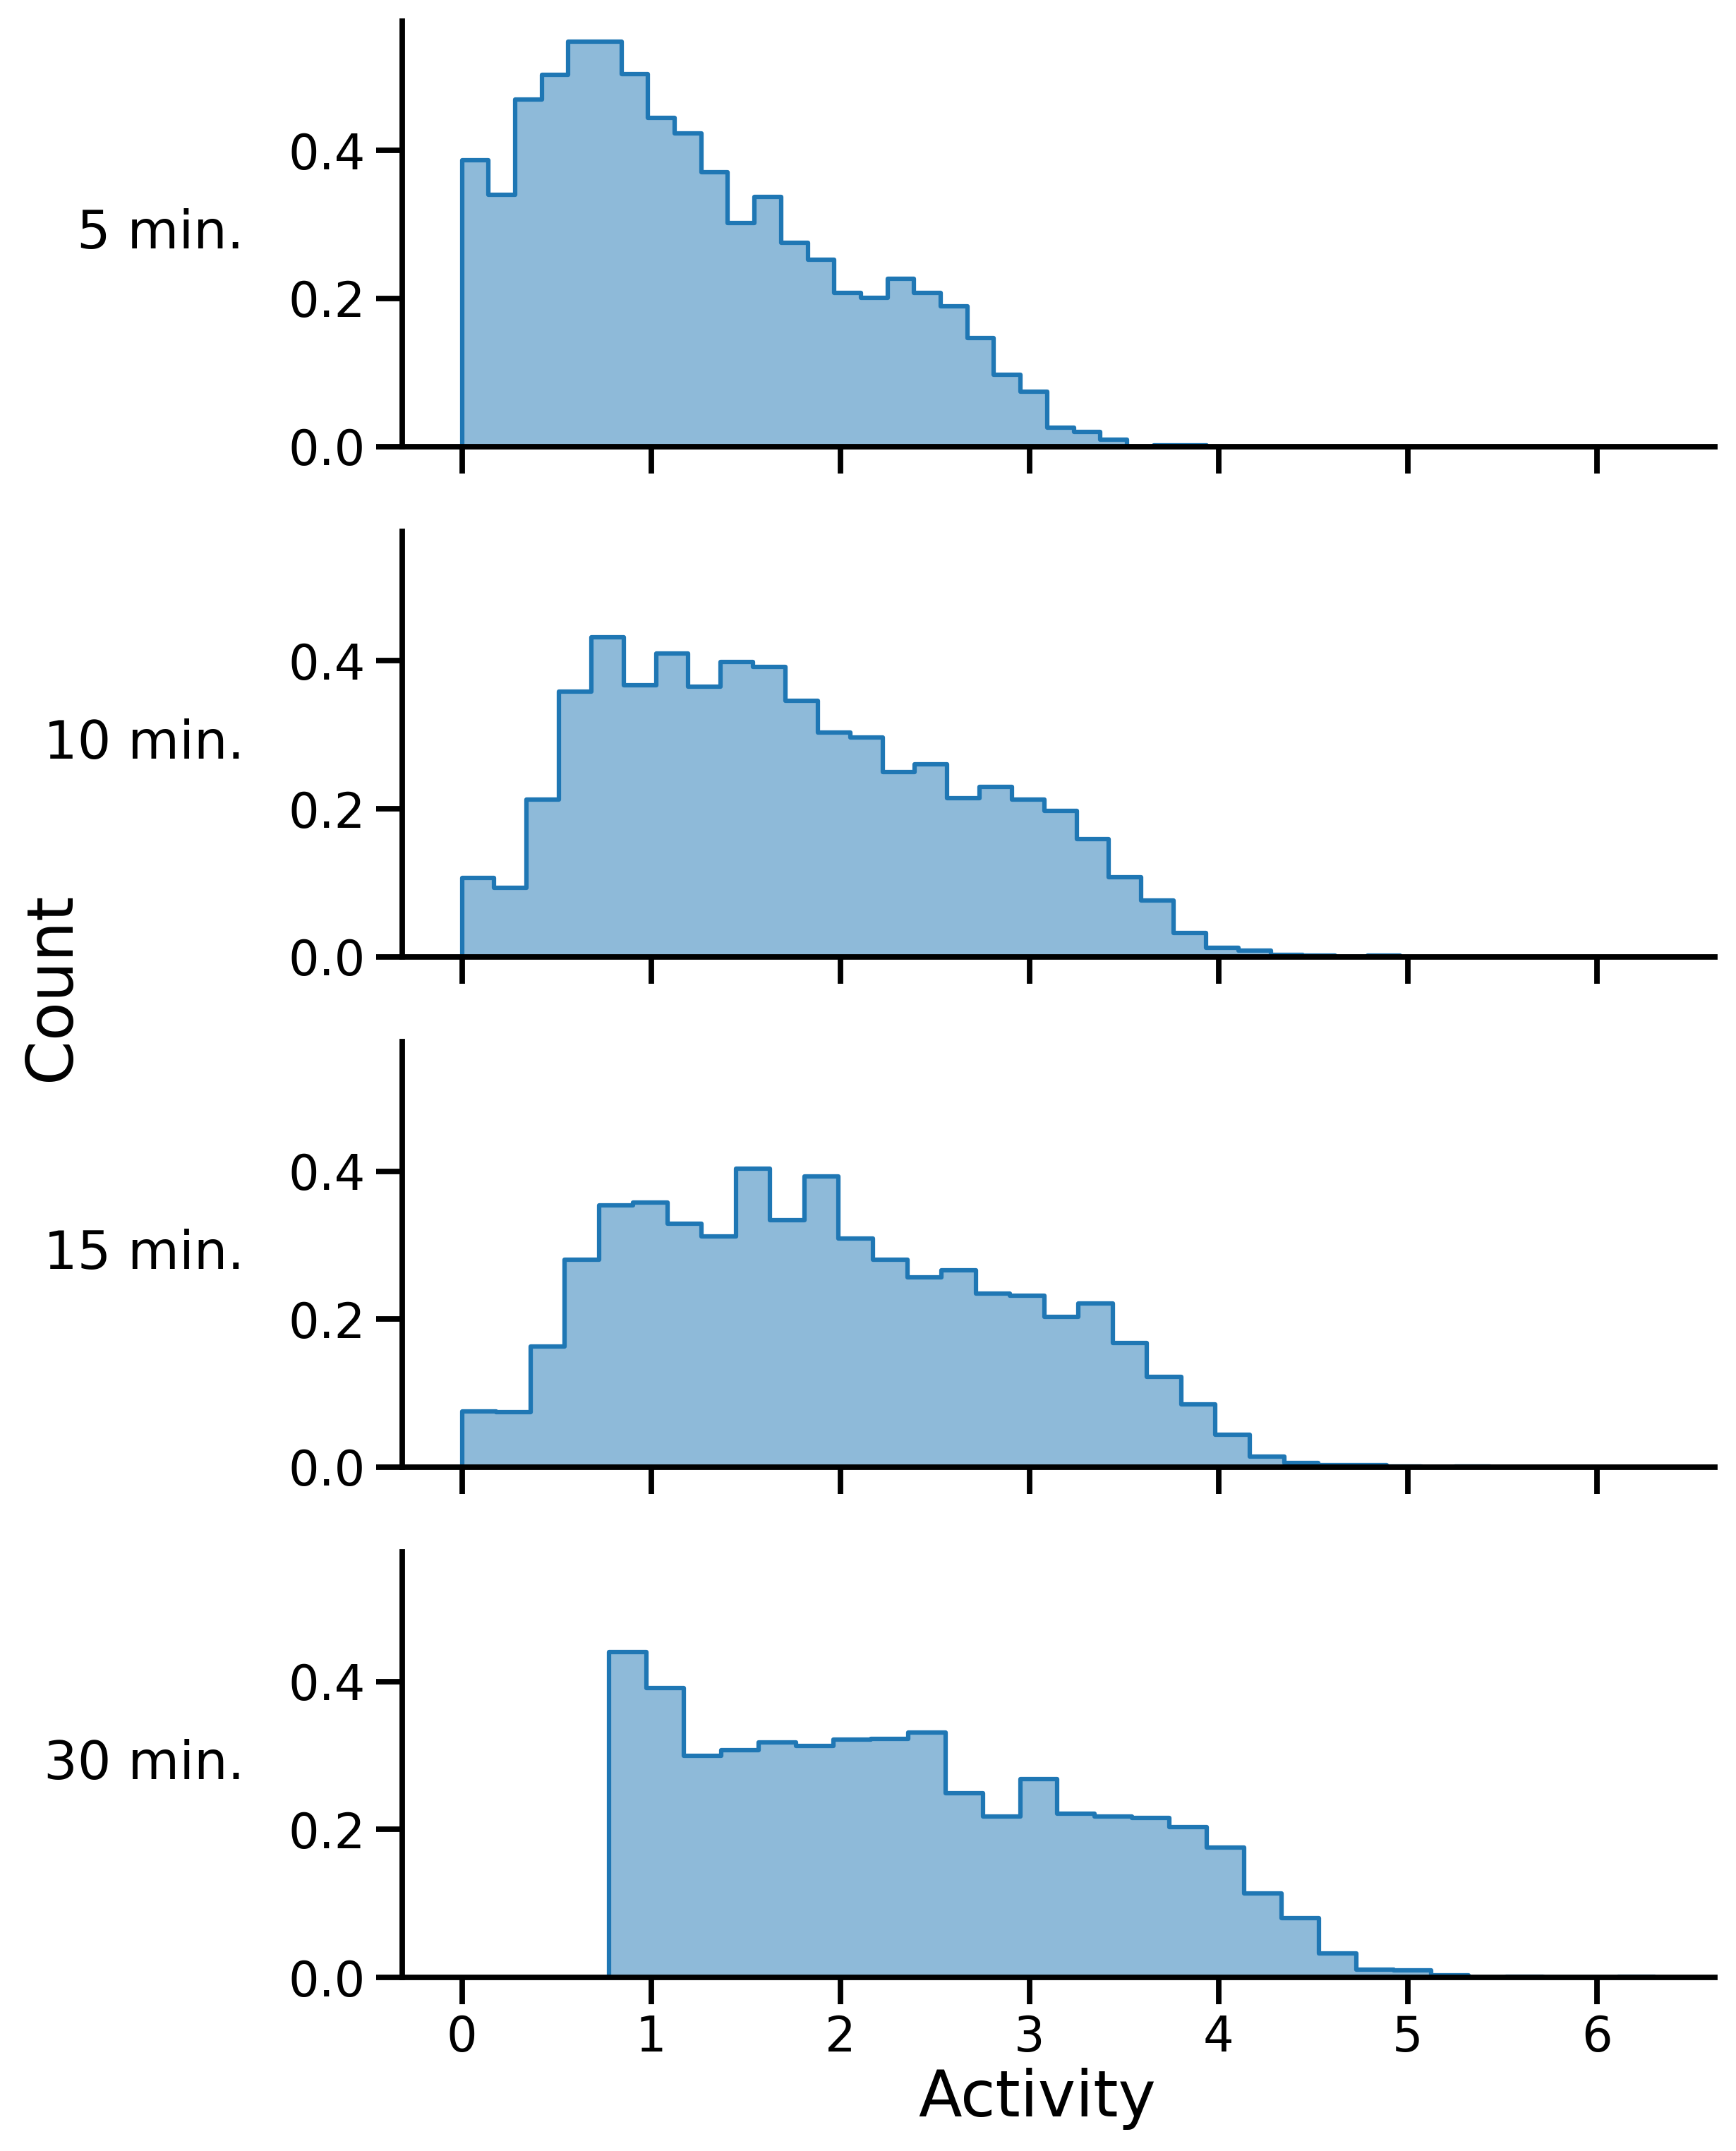

In [118]:
time_normalization_helpers.plot_hists_over_time(activities_norm[activities_norm["time"] != 0], column = "activity_norm")

# 2. plotting raw vs baseline activities

In [119]:
max_activities = activities_norm.groupby("ADseq")[["activity", "activity_norm"]].max().reset_index()
max_activities = pd.merge(max_activities, activities_norm[activities_norm["time"] == 0][["ADseq", "activity"]].rename(columns = {"activity" : "activity_t0"}))
max_activities

,ADseq,activity,activity_norm,activity_t0
0,AAAQHVPAADGQWLALFPHPSSIDFDFNSFHQSFSSPPPH,4.128912,3.692619,0.436294
1,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.813740,1.210488,0.603252
2,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.291359,2.359397,-0.068038
3,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.729031,2.032776,-0.303746
4,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,3.629833,2.527994,1.101839
...,...,...,...,...
4708,YTNLTTPGTSYIDSPLYIADSTDTSPLFATDGLGADADSW,3.410627,3.343357,0.067270
4709,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,3.930645,3.613299,0.317346
4710,YTTASSSSFSSASANILPRDFSVFTTDSQSSWLPSSSPSL,2.825109,2.525724,0.299384
4711,YVEGLRWVTWGQMGHVELSPVSRFTATIPSHDFQSFVTDH,1.399895,1.398243,0.001652


Pearson r = 0.691
Spearman r = 0.687, p = 0.00e+00


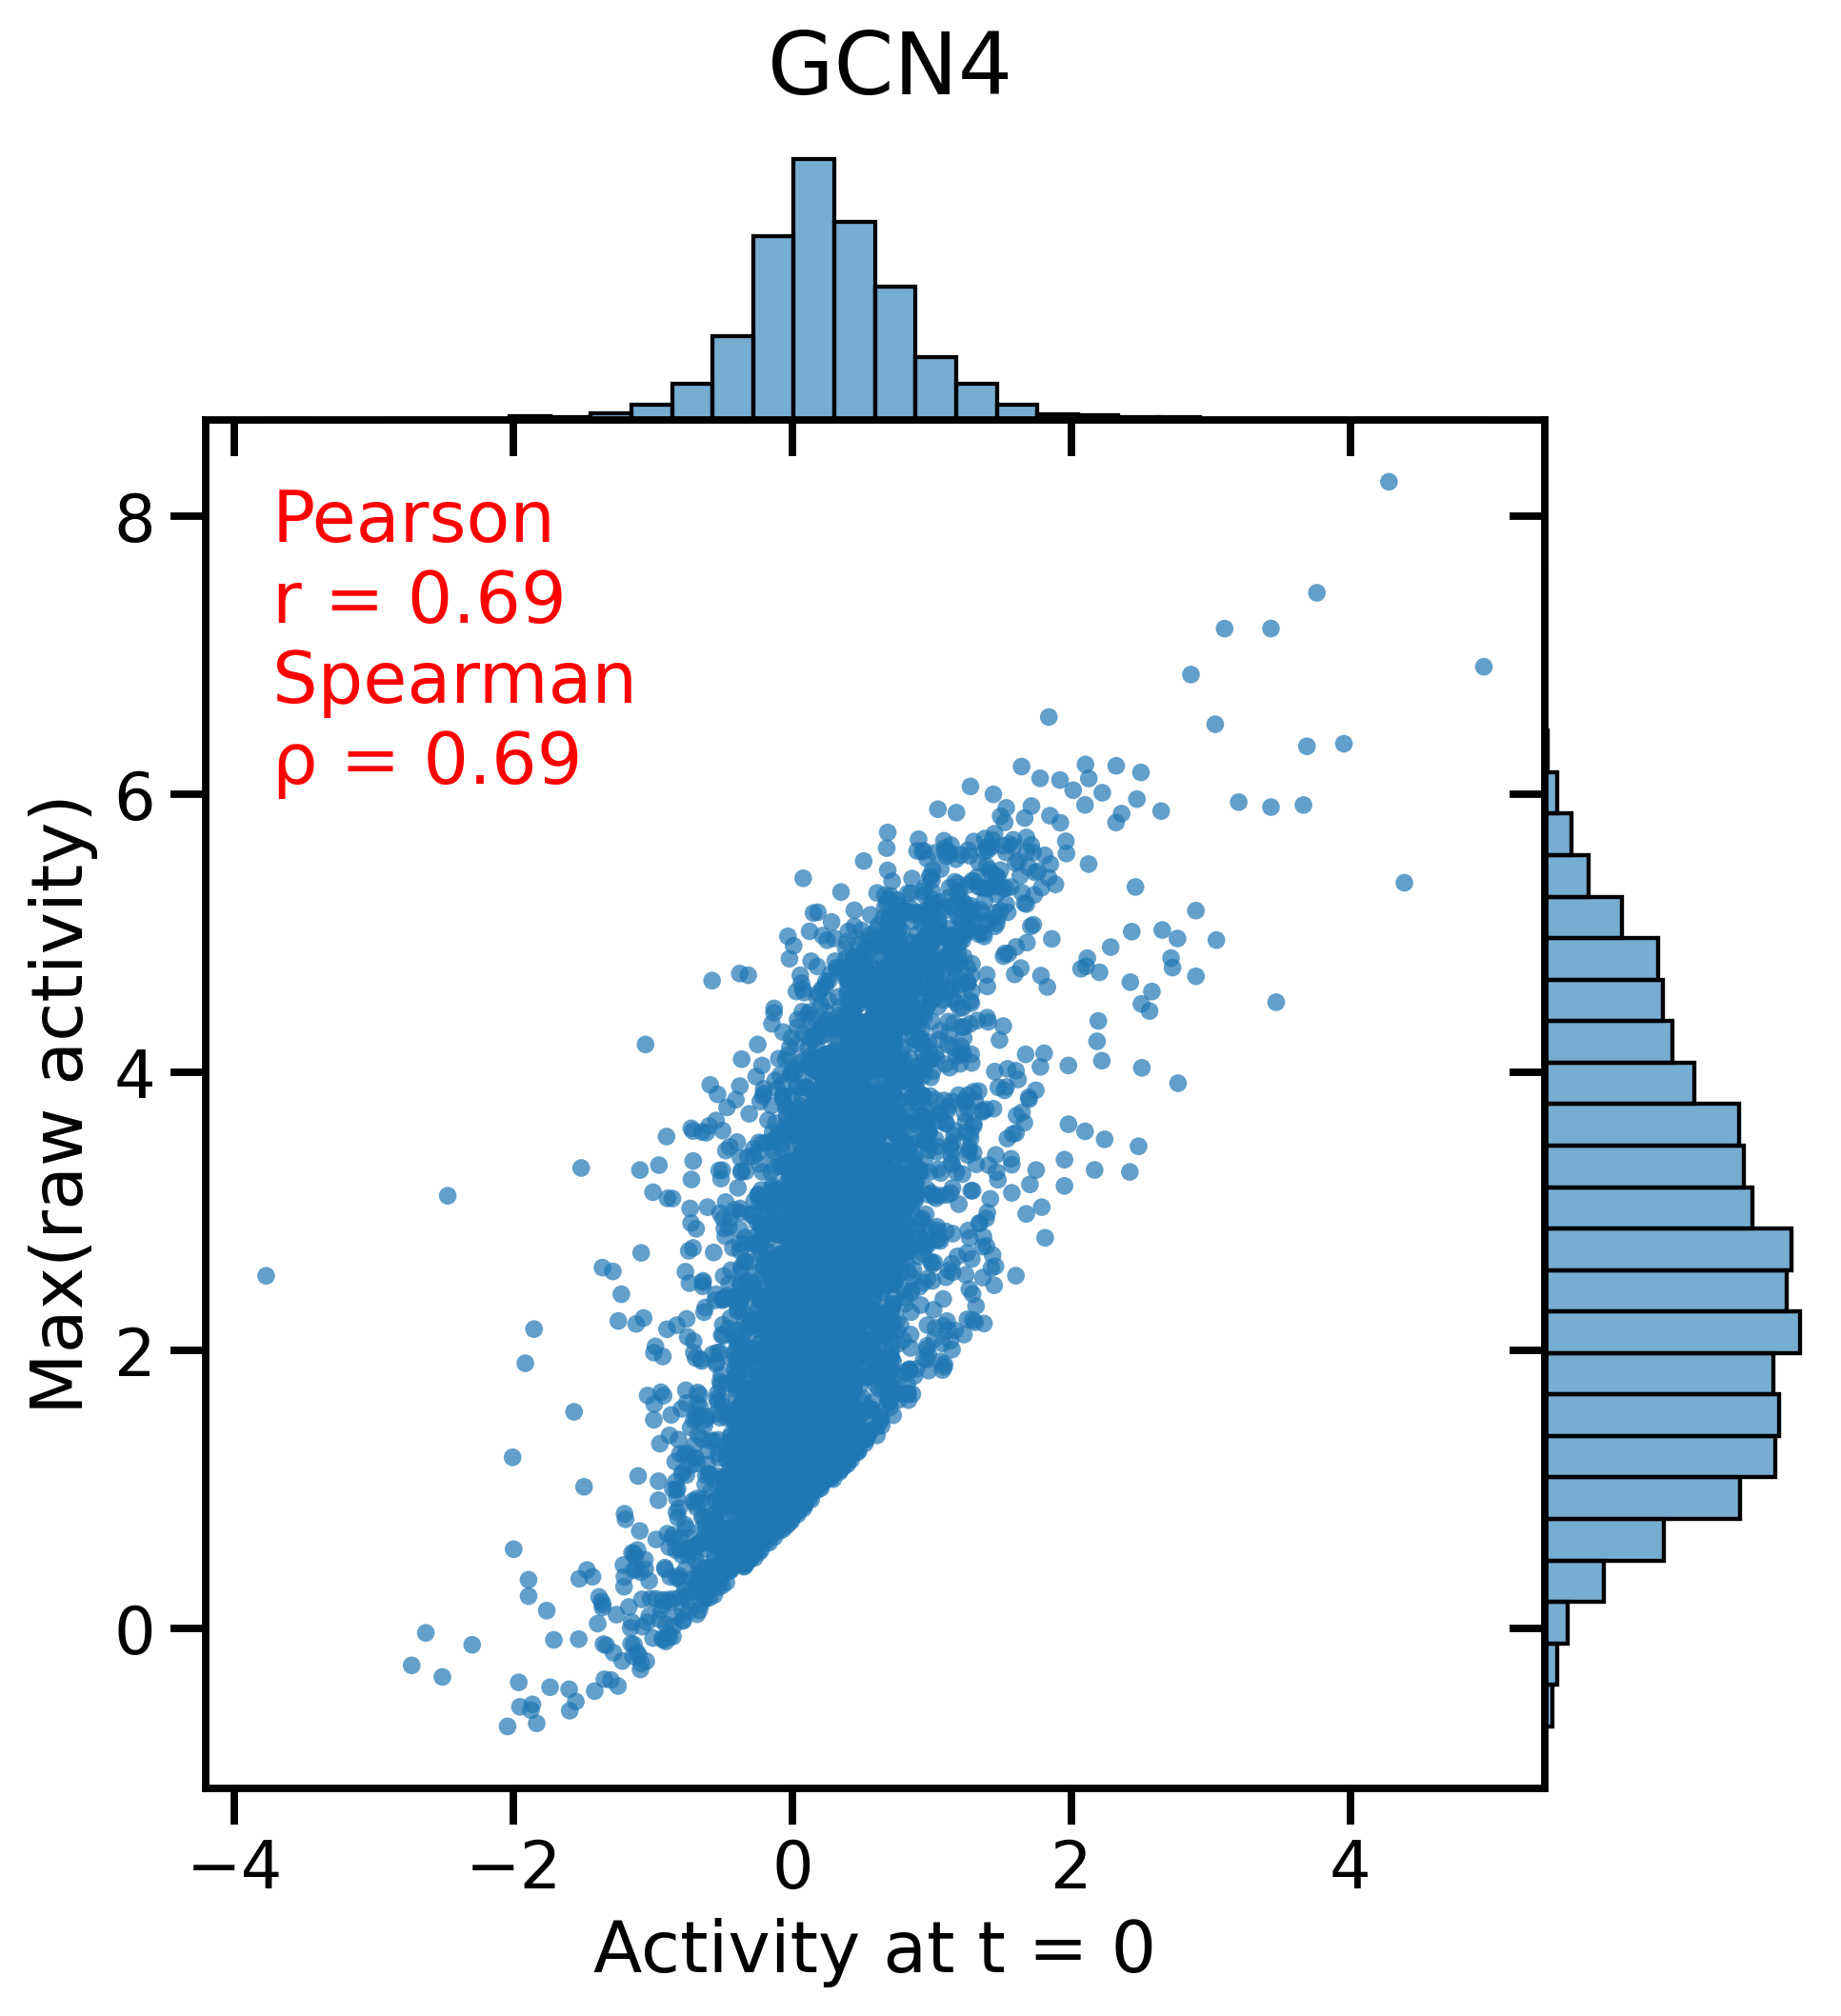

In [120]:
## Plotting
x = max_activities["activity_t0"]
y = max_activities["activity"]

# correlations
pearson_r = np.corrcoef(x, y)[0, 1]
spearman_r, spearman_p = spearmanr(x, y)

print(f"Pearson r = {pearson_r:.3f}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.2e}")

sns.set_context('talk')

# joint plot with marginal histograms
g = sns.JointGrid(data=max_activities, x="activity_t0", y="activity", height=7, space=0)

# main scatter
g.plot_joint(
    sns.scatterplot,
    alpha=0.7,
    edgecolor='none',
    s=20
)

# marginal histograms
g.plot_marginals(
    sns.histplot,
    bins=30,
    alpha=0.6
)

# labels
g.set_axis_labels("Activity at t = 0", "Max(raw activity)")

# annotation
g.ax_joint.text(
    0.05, 0.95,
    f"Pearson\nr = {pearson_r:.2f}\nSpearman\nρ = {spearman_r:.2f}",
    transform=g.ax_joint.transAxes,
    ha='left',
    va='top',
    color = 'red'
)

g.fig.set_dpi(300)
g.fig.suptitle("GCN4", y=1.02)

plt.show()

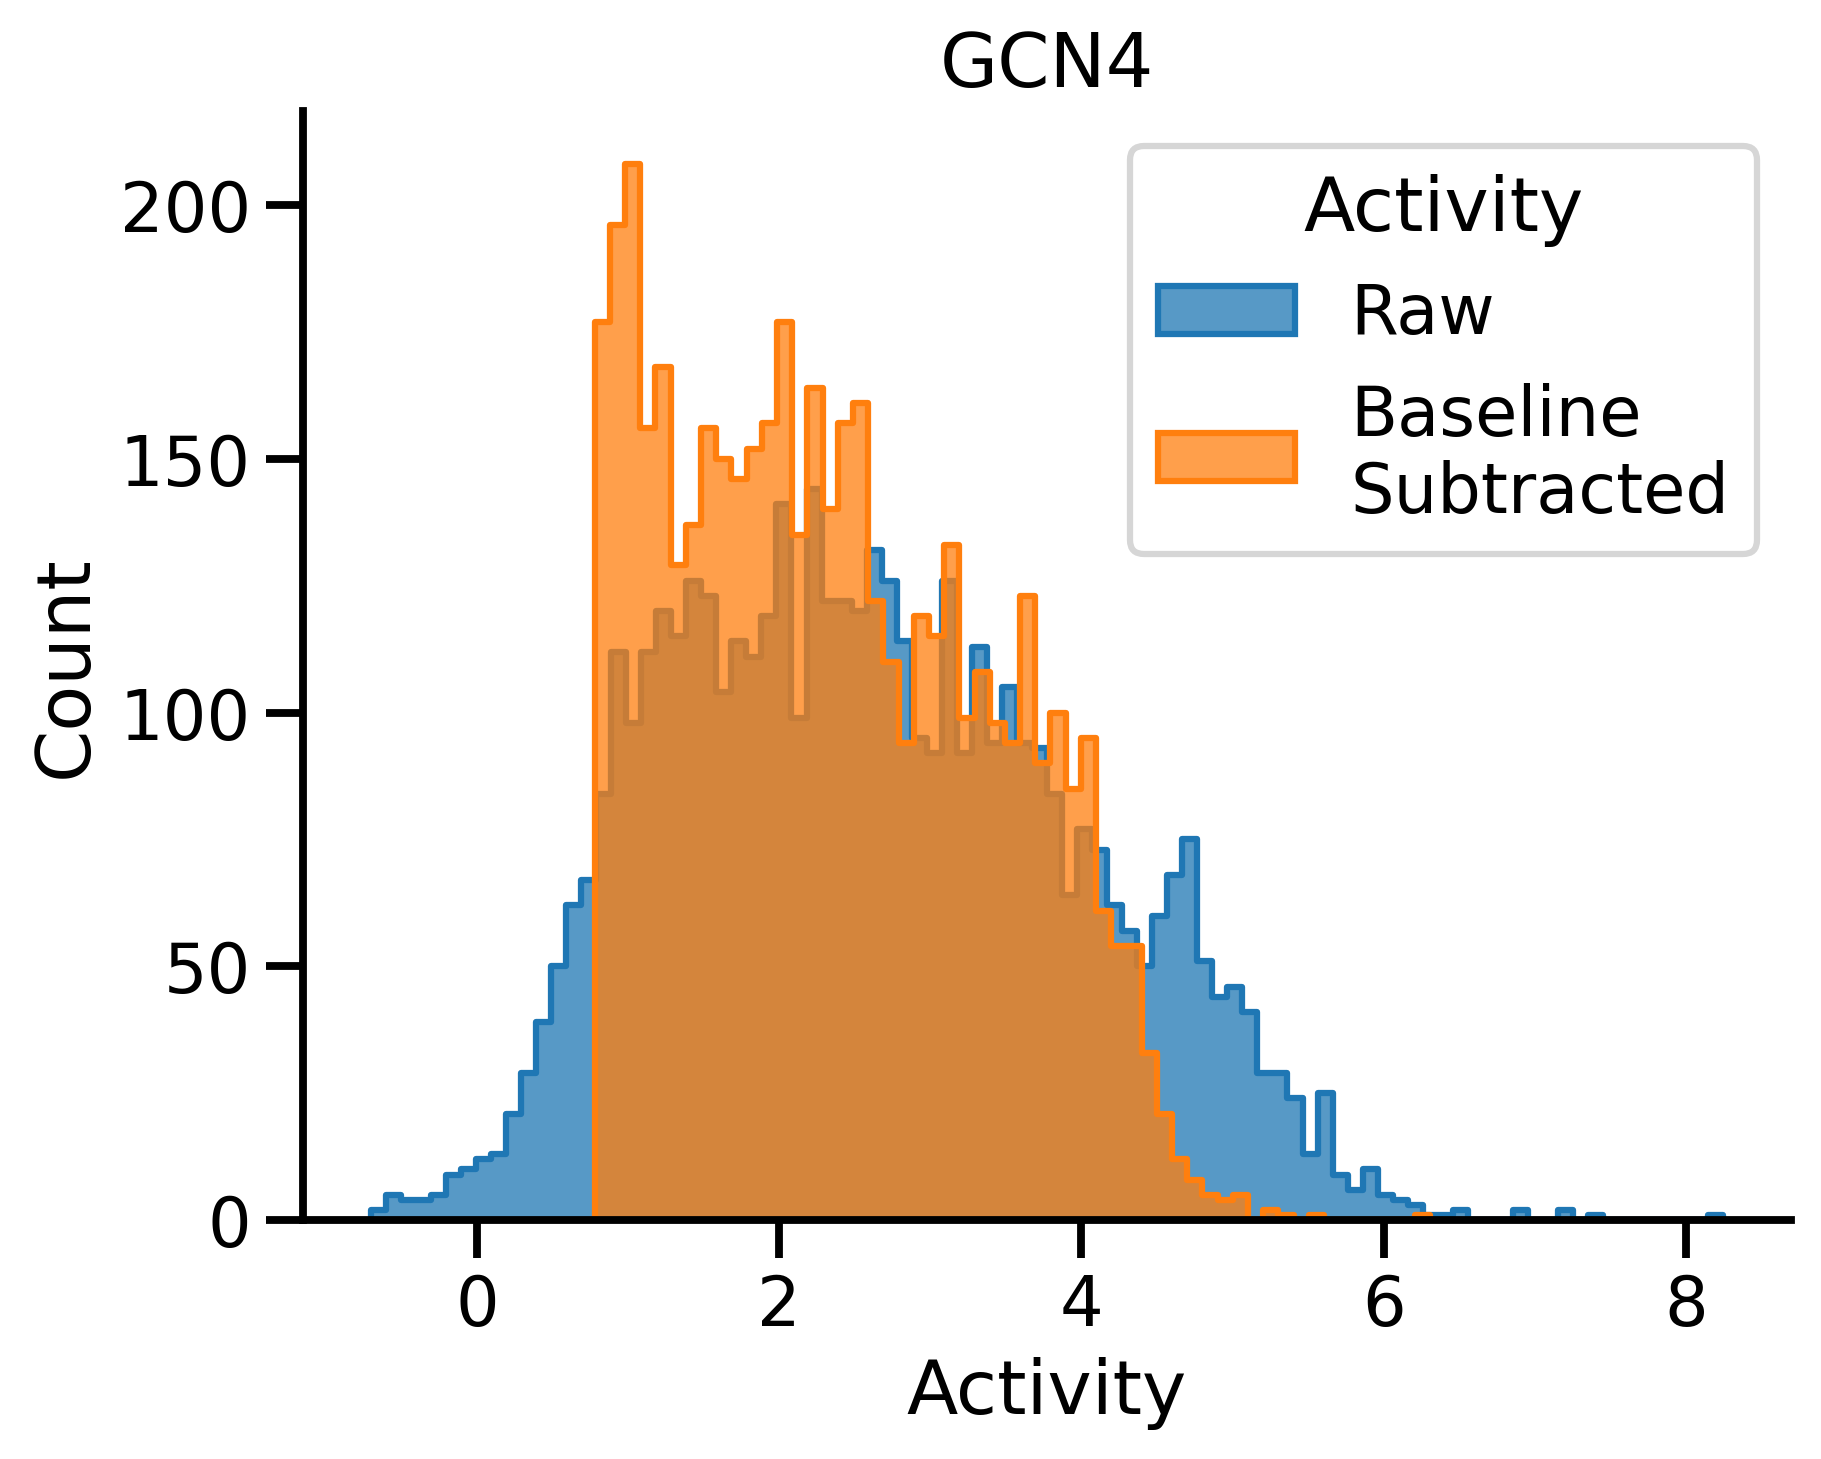

In [121]:
sns.set_context('talk')
plt.figure(dpi = 300)
plt.title("GCN4")
sns.histplot(data = max_activities, x = "activity", binwidth = 0.1, element ='step', label = "Raw")
sns.histplot(data = max_activities, x = "activity_norm", binwidth = 0.1, element ='step', label = "Baseline\nSubtracted")
plt.legend(title = "Activity")
plt.xlabel("Activity")
sns.despine()
plt.show()


Pearson r = 0.901
Spearman r = 0.915, p = 0.00e+00


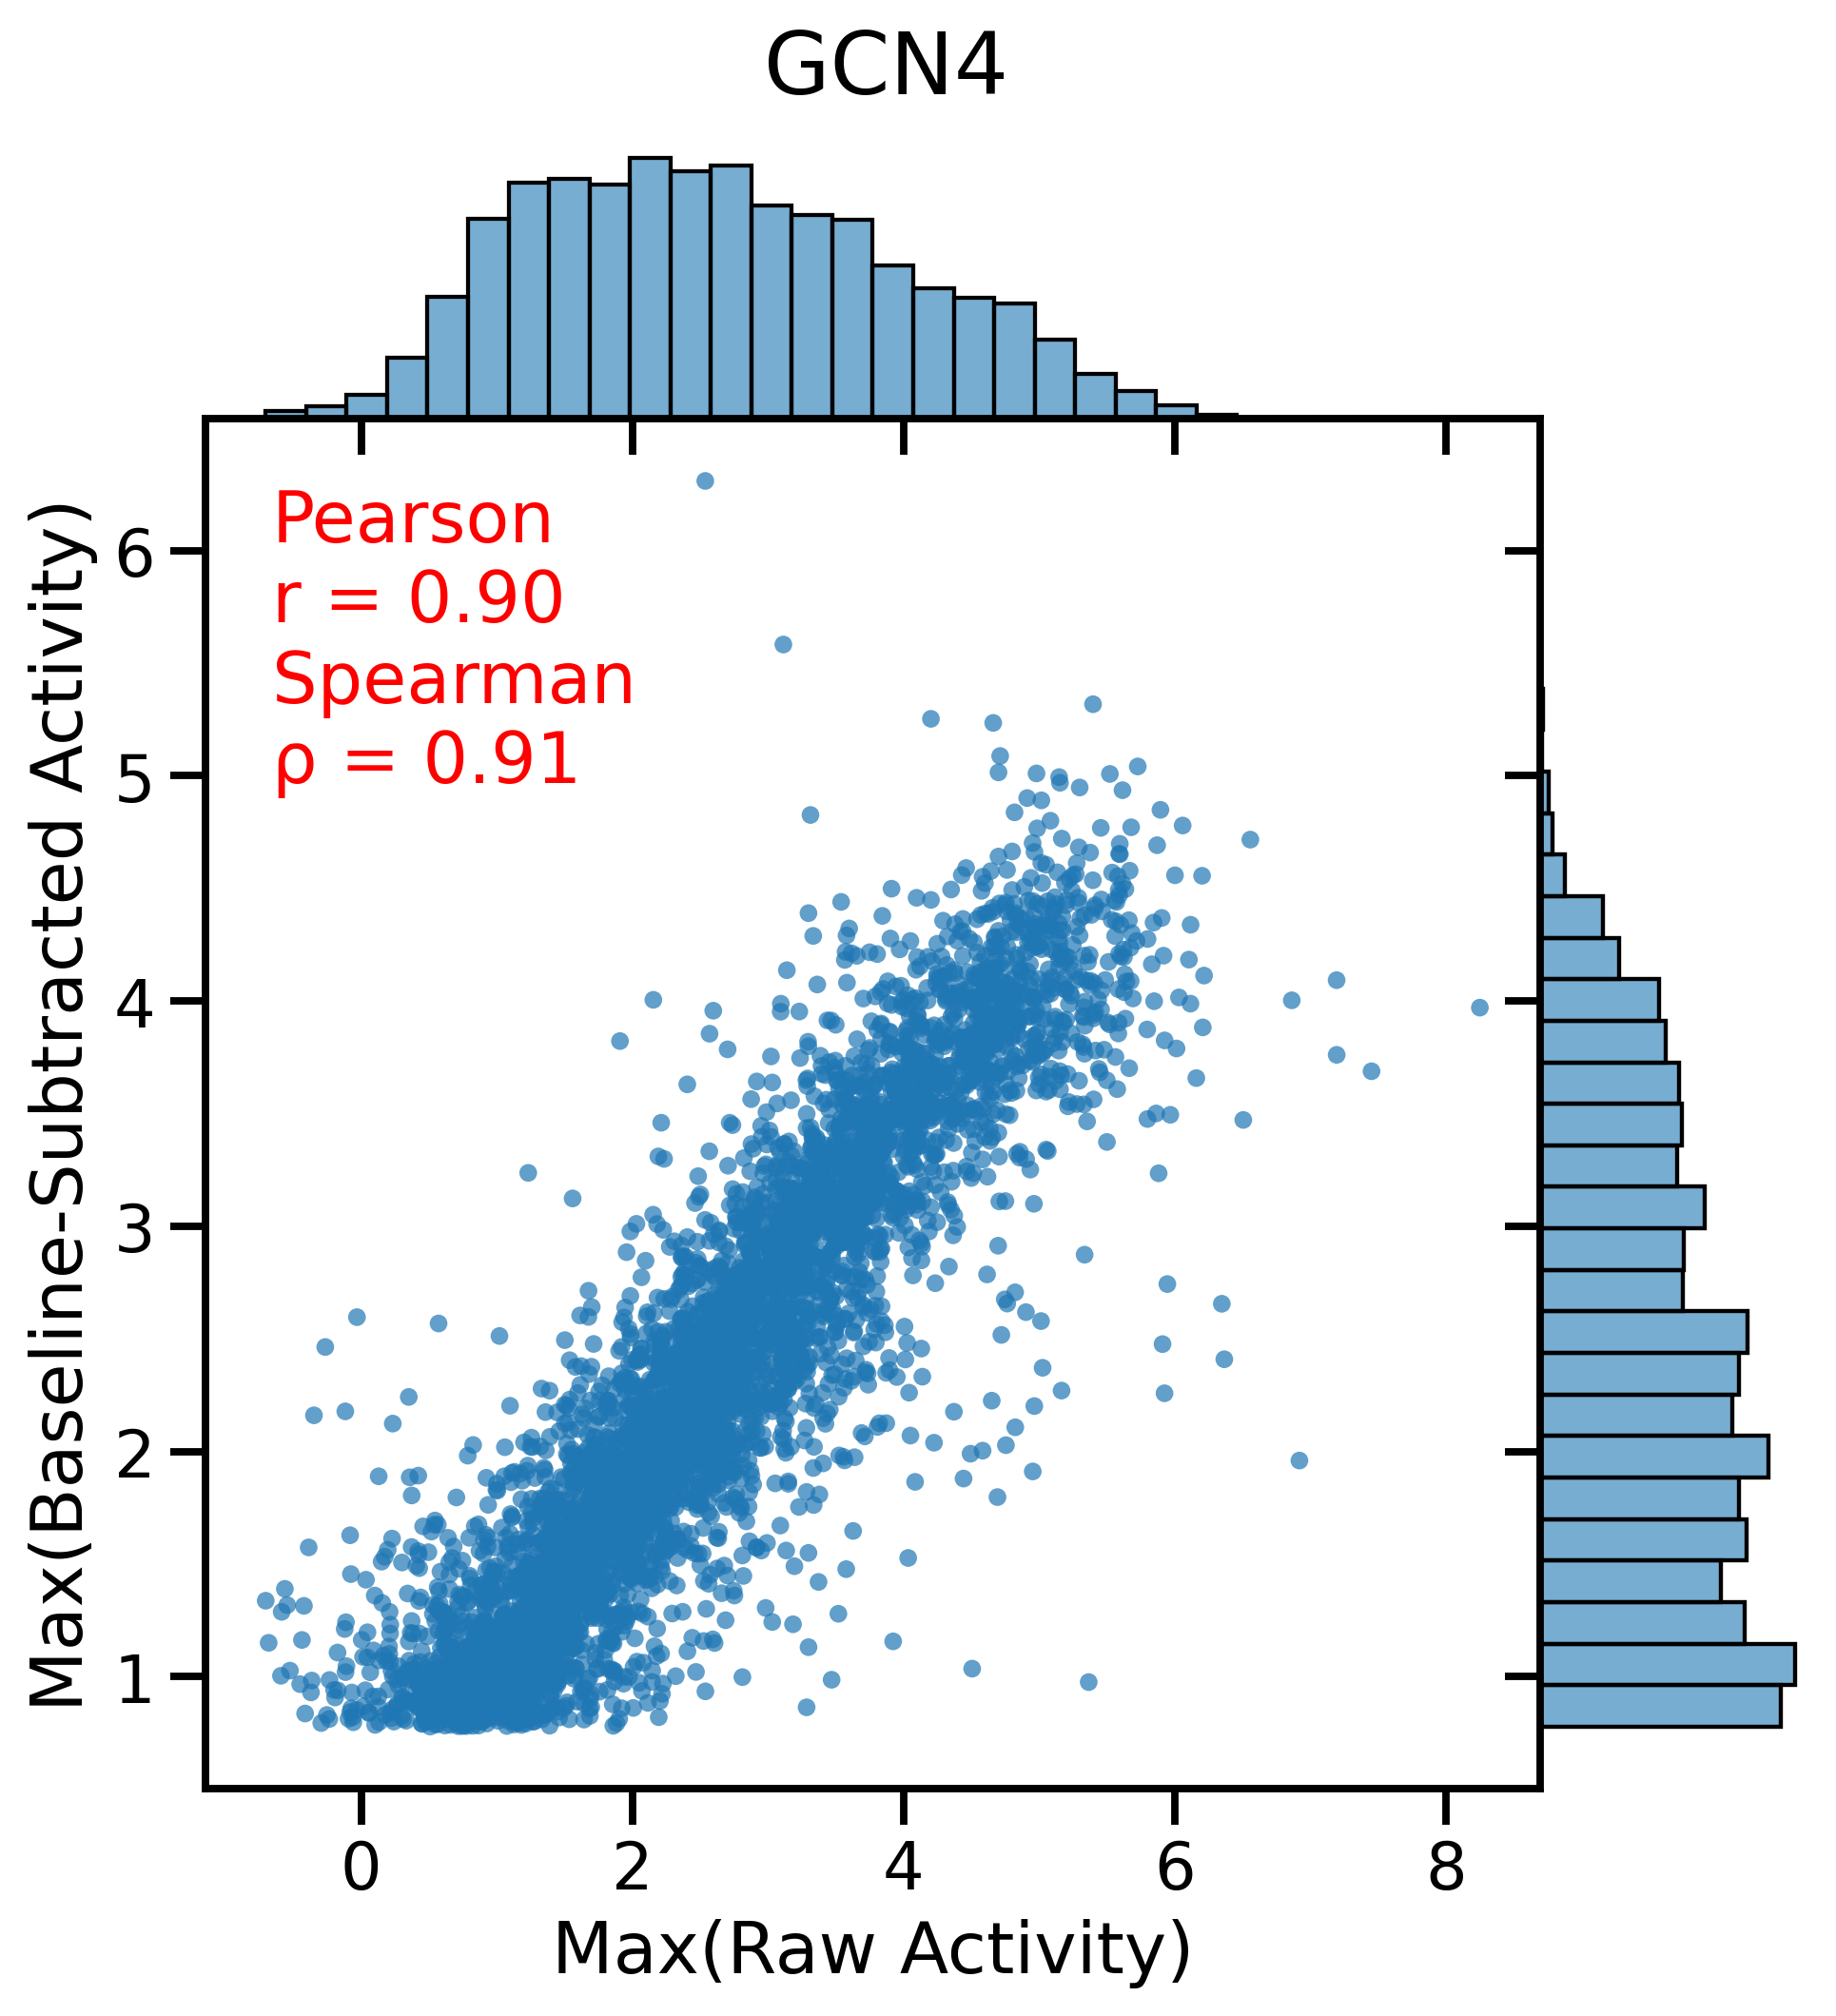

In [122]:
## Plotting

x = max_activities["activity"]
y = max_activities["activity_norm"]

# correlations
pearson_r = np.corrcoef(x, y)[0, 1]
spearman_r, spearman_p = spearmanr(x, y)

print(f"Pearson r = {pearson_r:.3f}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.2e}")

sns.set_context("talk")

# joint plot
g = sns.JointGrid(data=max_activities, x="activity", y="activity_norm", height=7, space=0)

# main scatter
g.plot_joint(
    sns.scatterplot,
    alpha=0.7,
    edgecolor="none",
    s=20
)

# marginals
g.plot_marginals(
    sns.histplot,
    bins=30,
    alpha=0.6
)

# identity line (perfect agreement)
max_val = max(x.max(), y.max())
#g.ax_joint.plot([0, max_val], [0, max_val], "--", color="gray", linewidth=1)

# axis labels
g.set_axis_labels("Max(Raw Activity)", "Max(Baseline-Subtracted Activity)")

# annotation
g.ax_joint.text(
    0.05, 0.95,
    f"Pearson\nr = {pearson_r:.2f}\nSpearman\nρ = {spearman_r:.2f}",
    transform=g.ax_joint.transAxes,
    ha="left",
    va="top",
    color="red"
)

g.fig.set_dpi(300)
g.fig.suptitle("GCN4", y=1.02)

plt.show()